In [1]:
import xarray as xr

# MET 359 Assignment — Uganda Climate Analysis
## CRU TS4.07 Monthly Precipitation Data (1990–2020)

**Assigned Country:** Uganda  
**Variable:** Monthly Precipitation (pre)  
**Dataset:** CRU TS4.07

---

In [10]:
ds = xr.open_mfdataset('cru*.nc').sel(time=slice('1990-01-01', '2020-12-31'))

In [11]:
ds

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360, time: 372)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 1990-01-16 1990-02-15 ... 2020-12-16
Data variables:
    pre      (time, lat, lon) float32 dask.array<chunksize=(12, 360, 720), meta=np.ndarray>
    stn      (time, lat, lon) float64 dask.array<chunksize=(12, 360, 720), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

## Part 1 — Data Acquisition and Exploration

### 1.2 Bounding Box Definition

Uganda is located in East Africa. The bounding box used to cover the country is:

| Parameter     | Value        |
|---------------|--------------|
| Min Latitude  | -1.5° (S)    |
| Max Latitude  |  4.5° (N)    |
| Min Longitude | 29.5° (E)    |
| Max Longitude | 35.0° (E)    |

This rectangle captures the full extent of Uganda including its border regions.

In [16]:
# # ============================================================
# # CELL 1 — Part 1.3: Data Loading and Initial Inspection
# # ============================================================

# import xarray as xr
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import warnings
# warnings.filterwarnings('ignore')

# # ── 1. Load the CRU TS4.07 precipitation NetCDF file ──────────────────────────
# # Update the path below to match where your downloaded .nc file is located
# # <-- UPDATE THIS PATH IF NEEDED

# # ── 2. Bounding Box for Uganda ─────────────────────────────────────────────────
# LAT_MIN, LAT_MAX = -1.5, 4.5
# LON_MIN, LON_MAX = 29.5, 35.0

# # ── 3. Slice to Uganda bounding box and period 1990–2020 ──────────────────────
# ds_uganda = ds.sel(
#     lat=slice(LAT_MIN, LAT_MAX),
#     lon=slice(LON_MIN, LON_MAX),
#     time=slice('1990-01-01', '2020-12-31')
# )

# # Extract the precipitation variable
# pre = ds_uganda['pre']   # units: mm/month

# # ── 4. Initial Inspection ──────────────────────────────────────────────────────
# print('=' * 55)
# print('DATASET OVERVIEW')
# print('=' * 55)
# print(ds_uganda)

# print('\n' + '=' * 55)
# print('PRECIPITATION VARIABLE DETAILS')
# print('=' * 55)
# print(pre)

# print('\n' + '=' * 55)
# print('DIMENSIONS AND COORDINATES')
# print('=' * 55)
# print(f"  Dimensions : {dict(pre.dims)}")
# print(f"  Time range : {str(pre.time.values[0])[:10]}  →  {str(pre.time.values[-1])[:10]}")
# print(f"  Lat range  : {float(pre.lat.min()):.2f}° to {float(pre.lat.max()):.2f}°")
# print(f"  Lon range  : {float(pre.lon.min()):.2f}° to {float(pre.lon.max()):.2f}°")
# print(f"  No. months : {pre.time.size}")
# print(f"  No. lat pts: {pre.lat.size}")
# print(f"  No. lon pts: {pre.lon.size}")
# print(f"  Units      : {pre.attrs.get('units', 'mm/month')}")
# print(f"  Long name  : {pre.attrs.get('long_name', 'Precipitation')}")

# print('\n' + '=' * 55)
# print('BASIC STATISTICS (spatial-temporal mean over Uganda)')
# print('=' * 55)
# print(f"  Min  precipitation: {float(pre.min()):.2f} mm/month")
# print(f"  Max  precipitation: {float(pre.max()):.2f} mm/month")
# print(f"  Mean precipitation: {float(pre.mean()):.2f} mm/month")
# print('=' * 55)

In [17]:
# ============================================================
# CELL 1 — Part 1.3: Data Loading and Initial Inspection
# ============================================================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load the CRU TS4.07 precipitation NetCDF file ─────────────
# If file is still .gz, xarray can open it directly


print("=" * 60)
print("FULL DATASET TIME RANGE")
print("=" * 60)
print(f"Start:", str(ds.time.values[0])[:10])
print(f"End  :", str(ds.time.values[-1])[:10])
print("=" * 60)


# ── 2. Bounding Box for Uganda ───────────────────────────────────
LAT_MIN, LAT_MAX = -1.5, 4.5
LON_MIN, LON_MAX = 29.5, 35.0

# Handle latitude ordering (CRU lat usually runs 89.75 → -89.75)
if ds.lat[0] > ds.lat[-1]:
    lat_slice = slice(LAT_MAX, LAT_MIN)
else:
    lat_slice = slice(LAT_MIN, LAT_MAX)

# Automatically limit time slice to available years
TIME_START = str(ds.time.values[0])[:10]
TIME_END   = str(ds.time.values[-1])[:10]

# ── 3. Slice to Uganda bounding box ──────────────────────────────
ds_uganda = ds.sel(
    lat=lat_slice,
    lon=slice(LON_MIN, LON_MAX),
    time=slice(TIME_START, TIME_END)
)

# Extract precipitation variable
pre = ds_uganda['pre']   # units: mm/month


# ── 4. Initial Inspection ─────────────────────────────────────────
print("\n" + "=" * 60)
print("UGANDA SUBSET OVERVIEW")
print("=" * 60)
print(ds_uganda)

print("\n" + "=" * 60)
print("PRECIPITATION VARIABLE DETAILS")
print("=" * 60)
print(pre)

print("\n" + "=" * 60)
print("DIMENSIONS AND COORDINATES")
print("=" * 60)
print(f"Dimensions       : {pre.dims}")
print(f"Time range       : {str(pre.time.values[0])[:10]} → {str(pre.time.values[-1])[:10]}")
print(f"Latitude range   : {float(pre.lat.min()):.2f}° to {float(pre.lat.max()):.2f}°")
print(f"Longitude range  : {float(pre.lon.min()):.2f}° to {float(pre.lon.max()):.2f}°")
print(f"Number of months : {pre.time.size}")
print(f"Latitude points  : {pre.lat.size}")
print(f"Longitude points : {pre.lon.size}")
print(f"Units            : {pre.attrs.get('units', 'mm/month')}")
print(f"Long name        : {pre.attrs.get('long_name', 'Precipitation')}")

print("\n" + "=" * 60)
print("BASIC STATISTICS (Uganda spatial-temporal)")
print("=" * 60)
print(f"Minimum precipitation : {float(pre.min()):.2f} mm/month")
print(f"Maximum precipitation : {float(pre.max()):.2f} mm/month")
print(f"Mean precipitation    : {float(pre.mean()):.2f} mm/month")
print("=" * 60)

FULL DATASET TIME RANGE
Start: 1990-01-16
End  : 2020-12-16

UGANDA SUBSET OVERVIEW
<xarray.Dataset>
Dimensions:  (lon: 11, lat: 12, time: 372)
Coordinates:
  * lon      (lon) float32 29.75 30.25 30.75 31.25 ... 33.25 33.75 34.25 34.75
  * lat      (lat) float32 -1.25 -0.75 -0.25 0.25 0.75 ... 2.75 3.25 3.75 4.25
  * time     (time) datetime64[ns] 1990-01-16 1990-02-15 ... 2020-12-16
Data variables:
    pre      (time, lat, lon) float32 dask.array<chunksize=(12, 12, 11), meta=np.ndarray>
    stn      (time, lat, lon) float64 dask.array<chunksize=(12, 12, 11), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access

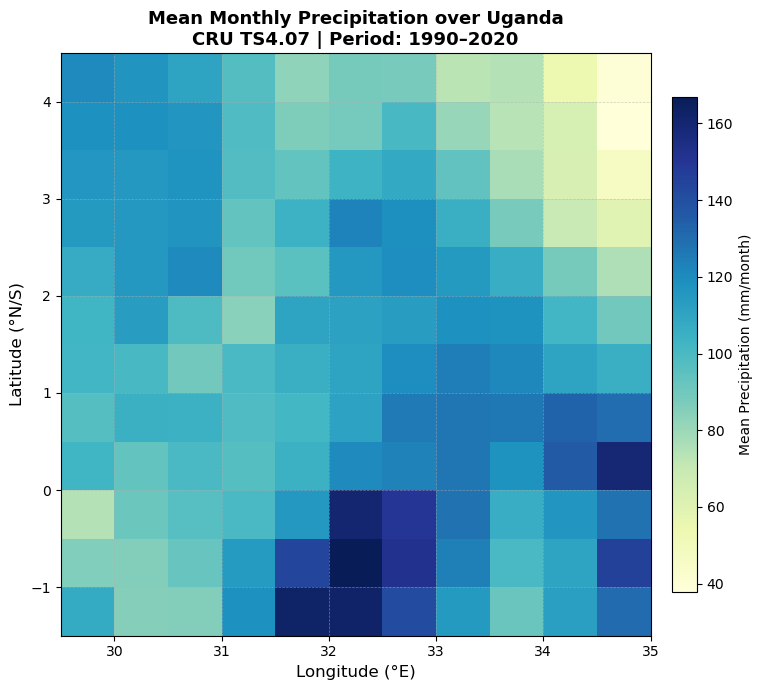

Figure saved as: Fig1_Mean_Precipitation_Uganda.png


In [18]:
# ============================================================
# CELL 2 — Part 1.4: Mean Precipitation Spatial Map (1990–2020)
# ============================================================

# ── Compute the temporal mean (average over all months 1990–2020) ──────────────
pre_mean = pre.mean(dim='time')   # result shape: (lat, lon)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

plot = pre_mean.plot(
    ax=ax,
    cmap='YlGnBu',
    cbar_kwargs={
        'label': 'Mean Precipitation (mm/month)',
        'shrink': 0.85,
        'pad': 0.03
    }
)

# Gridlines and labels
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N/S)', fontsize=12)
ax.set_title(
    'Mean Monthly Precipitation over Uganda\n'
    'CRU TS4.07 | Period: 1990–2020',
    fontsize=13, fontweight='bold'
)

# Add a simple grid
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# Add bounding box extent markers for reference
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)

plt.tight_layout()
plt.savefig('Fig1_Mean_Precipitation_Uganda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as: Fig1_Mean_Precipitation_Uganda.png")

PART 2 — TEMPORAL ANALYSIS SUMMARY
  Mean annual precipitation : 106.18 mm/month
  Standard deviation (σ)    : 9.10 mm/month
  Coefficient of variation  : 8.6%
  Linear slope              : 0.5508 mm/month/year
  Intercept                 : -998.22
  Trend interpretation      : Trend: +0.551 mm/month per year  (INCREASING)


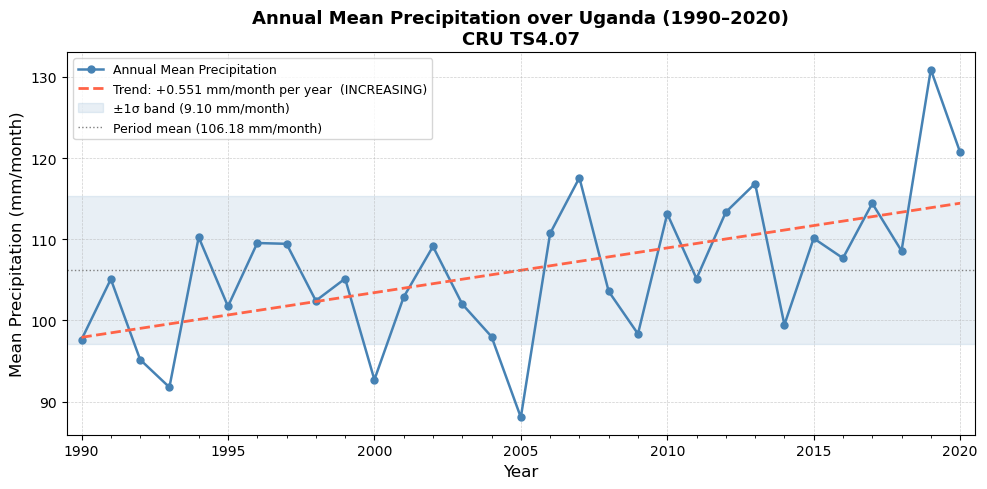

Figure saved as: Fig2_Annual_Precipitation_Trend_Uganda.png


In [13]:
# ============================================================
# CELL 3 — Part 2: Temporal Analysis
#   2.1 Annual Mean Precipitation Time Series
#   2.2 Trend Analysis
#   2.3 Variability Analysis
# ============================================================

# ── 2.1 Annual Mean Precipitation ─────────────────────────────────────────────
# Step 1: Spatial average over Uganda bounding box (area-weighted mean)
pre_spatial_mean = pre.mean(dim=['lat', 'lon'])   # shape: (time,)

# Step 2: Resample to annual mean
pre_annual = pre_spatial_mean.resample(time='1YE').mean()  # mm/month annual avg

# Extract year and values as numpy arrays for trend fitting
years  = pre_annual.time.dt.year.values.astype(float)
values = pre_annual.values

# ── 2.2 Trend Analysis — Linear Fit ───────────────────────────────────────────
slope, intercept = np.polyfit(years, values, 1)
trend_line = slope * years + intercept

# Interpret trend direction
if slope > 0.05:
    trend_label = f'Trend: +{slope:.3f} mm/month per year  (INCREASING)'
elif slope < -0.05:
    trend_label = f'Trend: {slope:.3f} mm/month per year  (DECREASING)'
else:
    trend_label = f'Trend: {slope:.3f} mm/month per year  (NO CLEAR TREND)'

# ── 2.3 Variability ────────────────────────────────────────────────────────────
std_dev = float(np.std(values, ddof=1))
mean_val = float(np.mean(values))
cv = (std_dev / mean_val) * 100   # Coefficient of Variation (%)

# ── Print Summary ──────────────────────────────────────────────────────────────
print('=' * 55)
print('PART 2 — TEMPORAL ANALYSIS SUMMARY')
print('=' * 55)
print(f"  Mean annual precipitation : {mean_val:.2f} mm/month")
print(f"  Standard deviation (σ)    : {std_dev:.2f} mm/month")
print(f"  Coefficient of variation  : {cv:.1f}%")
print(f"  Linear slope              : {slope:.4f} mm/month/year")
print(f"  Intercept                 : {intercept:.2f}")
print(f"  Trend interpretation      : {trend_label}")
print('=' * 55)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(years, values, marker='o', color='steelblue',
        linewidth=1.8, markersize=5, label='Annual Mean Precipitation')

ax.plot(years, trend_line, color='tomato', linewidth=2,
        linestyle='--', label=trend_label)

# Shade ±1 std dev band
ax.axhspan(mean_val - std_dev, mean_val + std_dev,
           alpha=0.12, color='steelblue', label=f'±1σ band ({std_dev:.2f} mm/month)')
ax.axhline(mean_val, color='grey', linewidth=1, linestyle=':', label=f'Period mean ({mean_val:.2f} mm/month)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Precipitation (mm/month)', fontsize=12)
ax.set_title(
    'Annual Mean Precipitation over Uganda (1990–2020)\n'
    'CRU TS4.07',
    fontsize=13, fontweight='bold'
)
ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=9, loc='best')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig('Fig2_Annual_Precipitation_Trend_Uganda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as: Fig2_Annual_Precipitation_Trend_Uganda.png")

---
## Part 3 — Spatial Patterns over Time

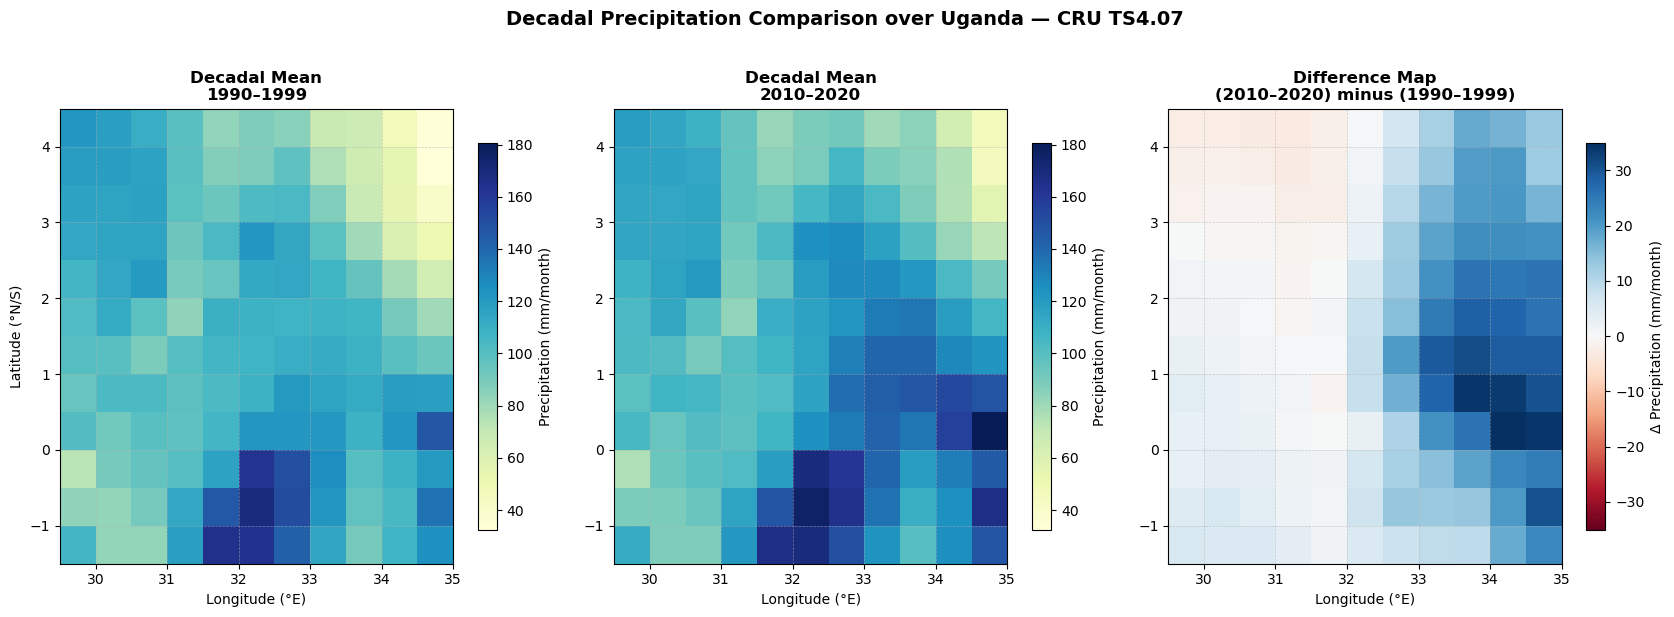

Figure saved as: Fig3_Decadal_Comparison_Uganda.png


In [14]:
# ============================================================
# CELL 4 — Part 3.1: Decadal Averages and Difference Map
# ============================================================

# ── Slice into two decades ─────────────────────────────────────────────────────
pre_1990s = pre.sel(time=slice('1990-01-01', '1999-12-31'))  # First decade
pre_2010s = pre.sel(time=slice('2010-01-01', '2020-12-31'))  # Recent decade

# ── Compute decadal means ──────────────────────────────────────────────────────
mean_1990s = pre_1990s.mean(dim='time')   # shape: (lat, lon)
mean_2010s = pre_2010s.mean(dim='time')   # shape: (lat, lon)

# ── Difference map: recent minus earlier ──────────────────────────────────────
diff_map = mean_2010s - mean_1990s        # positive = wetter recently

# ── Determine symmetric colorbar limits for difference map ────────────────────
max_abs = float(np.abs(diff_map).max())
vlim = np.ceil(max_abs)   # round up for clean limits

# ── Shared colorbar range for the two decadal maps ────────────────────────────
vmin_dec = float(min(mean_1990s.min(), mean_2010s.min()))
vmax_dec = float(max(mean_1990s.max(), mean_2010s.max()))

# ── Plot: 3 panels side by side ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# --- Panel 1: 1990–1999 ---
p1 = mean_1990s.plot(
    ax=axes[0], cmap='YlGnBu',
    vmin=vmin_dec, vmax=vmax_dec,
    cbar_kwargs={'label': 'Precipitation (mm/month)', 'shrink': 0.85}
)
axes[0].set_title('Decadal Mean\n1990–1999', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude (°E)', fontsize=10)
axes[0].set_ylabel('Latitude (°N/S)', fontsize=10)
axes[0].set_xlim(LON_MIN, LON_MAX)
axes[0].set_ylim(LAT_MIN, LAT_MAX)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# --- Panel 2: 2010–2020 ---
p2 = mean_2010s.plot(
    ax=axes[1], cmap='YlGnBu',
    vmin=vmin_dec, vmax=vmax_dec,
    cbar_kwargs={'label': 'Precipitation (mm/month)', 'shrink': 0.85}
)
axes[1].set_title('Decadal Mean\n2010–2020', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude (°E)', fontsize=10)
axes[1].set_ylabel('')
axes[1].set_xlim(LON_MIN, LON_MAX)
axes[1].set_ylim(LAT_MIN, LAT_MAX)
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# --- Panel 3: Difference Map ---
p3 = diff_map.plot(
    ax=axes[2], cmap='RdBu',
    vmin=-vlim, vmax=vlim,
    cbar_kwargs={'label': 'Δ Precipitation (mm/month)', 'shrink': 0.85}
)
axes[2].set_title('Difference Map\n(2010–2020) minus (1990–1999)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Longitude (°E)', fontsize=10)
axes[2].set_ylabel('')
axes[2].set_xlim(LON_MIN, LON_MAX)
axes[2].set_ylim(LAT_MIN, LAT_MAX)
axes[2].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

fig.suptitle(
    'Decadal Precipitation Comparison over Uganda — CRU TS4.07',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('Fig3_Decadal_Comparison_Uganda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as: Fig3_Decadal_Comparison_Uganda.png")

TOP 5 GRID POINTS — LARGEST PRECIPITATION INCREASE
(2010–2020 vs 1990–1999)
    lat    lon  delta_pre_mm_per_month
1 0.250 34.250                  34.814
2 0.250 34.750                  34.016
3 0.750 33.750                  33.970
4 0.750 34.250                  33.564
5 1.250 33.750                  31.414

TOP 5 GRID POINTS — LARGEST PRECIPITATION DECREASE
(2010–2020 vs 1990–1999)
    lat    lon  delta_pre_mm_per_month
1 4.250 31.250                  -3.098
2 3.750 31.250                  -2.883
3 4.250 30.750                  -2.771
4 4.250 29.750                  -2.690
5 4.250 30.250                  -2.618


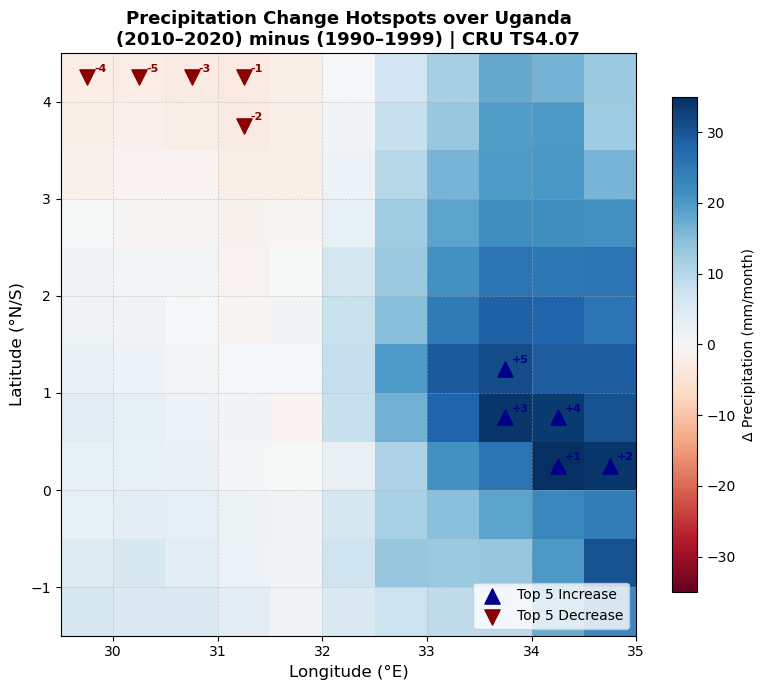

Figure saved as: Fig4_Hotspot_Map_Uganda.png


In [15]:
# ============================================================
# CELL 5 — Part 3.2: Hotspot Identification
#   Top 5 grid points with largest INCREASE
#   Top 5 grid points with largest DECREASE
# ============================================================

import pandas as pd

# ── Flatten the difference map into a 1D array with coordinates ───────────────
diff_df = diff_map.to_dataframe(name='delta_pre').reset_index()
diff_df = diff_df.dropna(subset=['delta_pre'])   # remove NaN (masked ocean/land cells)
diff_df.columns = ['lat', 'lon', 'delta_pre_mm_per_month']

# ── Top 5 INCREASES (largest positive change) ─────────────────────────────────
top5_increase = (
    diff_df.nlargest(5, 'delta_pre_mm_per_month')
    .reset_index(drop=True)
)
top5_increase.index += 1   # rank from 1

# ── Top 5 DECREASES (largest negative change) ─────────────────────────────────
top5_decrease = (
    diff_df.nsmallest(5, 'delta_pre_mm_per_month')
    .reset_index(drop=True)
)
top5_decrease.index += 1   # rank from 1

# ── Print tables ──────────────────────────────────────────────────────────────
print('=' * 60)
print('TOP 5 GRID POINTS — LARGEST PRECIPITATION INCREASE')
print('(2010–2020 vs 1990–1999)')
print('=' * 60)
print(top5_increase.to_string(
    index=True,
    float_format=lambda x: f"{x:.3f}"
))

print('\n' + '=' * 60)
print('TOP 5 GRID POINTS — LARGEST PRECIPITATION DECREASE')
print('(2010–2020 vs 1990–1999)')
print('=' * 60)
print(top5_decrease.to_string(
    index=True,
    float_format=lambda x: f"{x:.3f}"
))

# ── Plot: Hotspot Map overlaid on difference map ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

diff_map.plot(
    ax=ax, cmap='RdBu',
    vmin=-vlim, vmax=vlim,
    cbar_kwargs={'label': 'Δ Precipitation (mm/month)', 'shrink': 0.85}
)

# Mark top 5 increase points
ax.scatter(
    top5_increase['lon'], top5_increase['lat'],
    color='darkblue', marker='^', s=120, zorder=5,
    label='Top 5 Increase'
)

# Mark top 5 decrease points
ax.scatter(
    top5_decrease['lon'], top5_decrease['lat'],
    color='darkred', marker='v', s=120, zorder=5,
    label='Top 5 Decrease'
)

# Annotate increase points with rank
for rank, row in top5_increase.iterrows():
    ax.annotate(
        f'+{rank}', (row['lon'], row['lat']),
        textcoords='offset points', xytext=(5, 4),
        fontsize=8, color='darkblue', fontweight='bold'
    )

# Annotate decrease points with rank
for rank, row in top5_decrease.iterrows():
    ax.annotate(
        f'-{rank}', (row['lon'], row['lat']),
        textcoords='offset points', xytext=(5, 4),
        fontsize=8, color='darkred', fontweight='bold'
    )

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N/S)', fontsize=12)
ax.set_title(
    'Precipitation Change Hotspots over Uganda\n'
    '(2010–2020) minus (1990–1999) | CRU TS4.07',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig('Fig4_Hotspot_Map_Uganda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as: Fig4_Hotspot_Map_Uganda.png")

90th percentile threshold: 116.86 mm/month


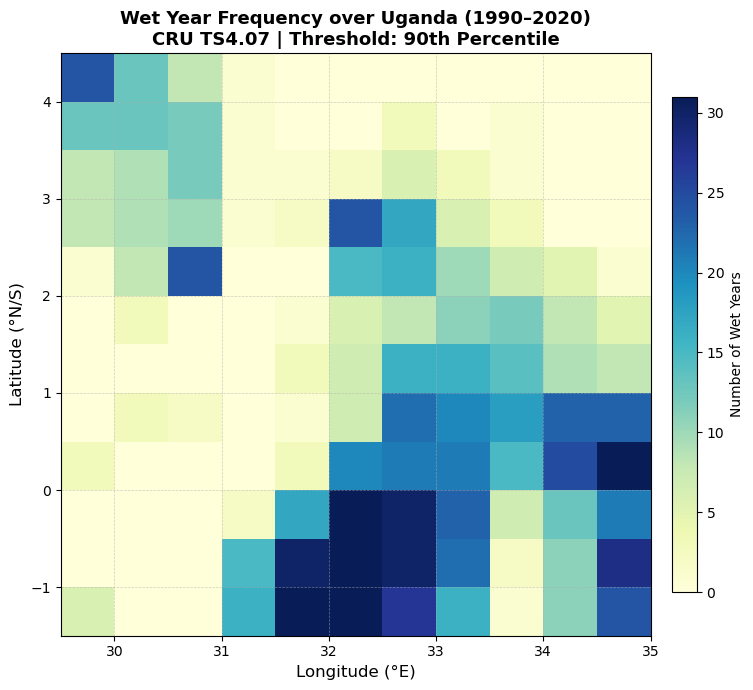

Figure saved as: Fig5_Wet_Year_Frequency_Uganda.png
Threshold used: 116.86 mm/month


In [27]:
# ── Step 1: Compute annual mean precipitation spatially averaged ──────────────
pre_annual_spatial = pre.mean(dim=['lat', 'lon']).resample(time='1YE').mean()

# ── Step 2: Convert to numpy and compute 90th percentile ─────────────────────
values_numpy = pre_annual_spatial.values
threshold = float(np.percentile(values_numpy, 90))
print(f"90th percentile threshold: {threshold:.2f} mm/month")

# ── Step 3: Compute annual mean at each grid cell ────────────────────────────
pre_annual_grid = pre.resample(time='1YE').mean()

# ── Step 4: Count how many years exceeded the threshold at each grid cell ─────
wet_year_count = (pre_annual_grid > threshold).sum(dim='time')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
wet_year_count.plot(
    ax=ax,
    cmap='YlGnBu',
    cbar_kwargs={
        'label': 'Number of Wet Years',
        'shrink': 0.85,
        'pad': 0.03
    }
)
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N/S)', fontsize=12)
ax.set_title(
    'Wet Year Frequency over Uganda (1990–2020)\n'
    'CRU TS4.07 | Threshold: 90th Percentile',
    fontsize=13, fontweight='bold'
)
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig('Fig5_Wet_Year_Frequency_Uganda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as: Fig5_Wet_Year_Frequency_Uganda.png")
print(f"Threshold used: {threshold:.2f} mm/month")

In [28]:
# ============================================================
# CELL 4b — Part 3.2: Hotspot Identification
# ============================================================

# ── Flatten the difference map into a 1D array with coordinates ───────────────
diff_df = diff_map.to_dataframe(name='delta_pre').reset_index()
diff_df = diff_df.dropna(subset=['delta_pre'])

# ── Convert mm/month → mm/year ────────────────────────────────────────────────
diff_df['delta_pre_yr'] = diff_df['delta_pre'] * 12

# ── Top 5 increases (largest positive change) ─────────────────────────────────
top5_increase = diff_df.nlargest(5, 'delta_pre_yr')[['lat', 'lon', 'delta_pre_yr']].reset_index(drop=True)
top5_increase.index += 1

# ── Top 5 decreases (largest negative change) ─────────────────────────────────
top5_decrease = diff_df.nsmallest(5, 'delta_pre_yr')[['lat', 'lon', 'delta_pre_yr']].reset_index(drop=True)
top5_decrease.index += 1

# ── Round for clean display ───────────────────────────────────────────────────
top5_increase = top5_increase.round({'lat': 3, 'lon': 3, 'delta_pre_yr': 3})
top5_decrease = top5_decrease.round({'lat': 3, 'lon': 3, 'delta_pre_yr': 3})

# ── Rename columns for the table ──────────────────────────────────────────────
col_map = {'lat': 'Latitude', 'lon': 'Longitude', 'delta_pre_yr': 'Δ Precipitation (mm/year)'}
top5_increase = top5_increase.rename(columns=col_map)
top5_decrease = top5_decrease.rename(columns=col_map)

# ── Print tables ──────────────────────────────────────────────────────────────
print('=' * 55)
print('PART 3.2 — HOTSPOT IDENTIFICATION')
print('=' * 55)
print('\n📈 Top 5 Grid Points — LARGEST INCREASE')
print(top5_increase.to_string())
print('\n📉 Top 5 Grid Points — LARGEST DECREASE')
print(top5_decrease.to_string())
print('=' * 55)

PART 3.2 — HOTSPOT IDENTIFICATION

📈 Top 5 Grid Points — LARGEST INCREASE
   Latitude  Longitude  Δ Precipitation (mm/year)
1      0.25      34.25                 417.763000
2      0.25      34.75                 408.187012
3      0.75      33.75                 407.636993
4      0.75      34.25                 402.766998
5      1.25      33.75                 376.967010

📉 Top 5 Grid Points — LARGEST DECREASE
   Latitude  Longitude  Δ Precipitation (mm/year)
1      4.25      31.25                 -37.176998
2      3.75      31.25                 -34.598999
3      4.25      30.75                 -33.256001
4      4.25      29.75                 -32.279999
5      4.25      30.25                 -31.410000
